# PROBLEM STATEMENT


<table>
  <tr><td>
    <img src="https://upload.wikimedia.org/wikipedia/commons/e/e6/Doctor_Checkup_Cartoon.svg"
alt="Fashion MNIST sprite"  length = "400" width="400">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1. Diabetes Classification Using ANNs
  </td></tr>
</table>



---
- This dataset is used to predict whether or not a patient has diabetes, based on given features/diagnostic measurements.
- Only female patients are considered with at least 21 years old of Pima Indian heritage.

- Inputs:
    - Pregnancies: Number of times pregnant
    - GlucosePlasma: glucose concentration a 2 hours in an oral glucose tolerance test
    - BloodPressure: Diastolic blood pressure (mm Hg)
    - Skin: ThicknessTriceps skin fold thickness (mm)
    - Insulin: 2-Hour serum insulin (mu U/ml)
    - BMI: Body mass index (weight in kg/(height in m)^2)
    - DiabetesPedigreeFunction: Diabetes pedigree function
    - Age: Age (years)
- Outputs:
    - Diabetes or no diabetes (0 or 1)
    
    
- Acknowledgements
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.


---








# STEP #0: IMPORT LIBRARIES

In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Prevent TensorFlow from reserving most GPU memory upfront

gpu = tf.config.experimental.list_physical_devices('GPU')
if gpu:
    try:
        tf.config.experimental.set_memory_growth(gpu[0], True)
    except RuntimeError as e:
        print(e)
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Visible GPUs:", gpu)

I0000 00:00:1774126774.293445  161835 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774126774.435288  161835 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774126775.789788  161835 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.21.0
Built with CUDA: True
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1774126777.947010  161835 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


# STEP #1: IMPORT DATASETS

In [2]:
df_diabetes = pd.read_csv("../data/diabetes.csv")
df_diabetes.reset_index(drop=True, inplace=True)
df_diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df_diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# STEP #2: CLEAN UP AND VISUALIZE DATASET

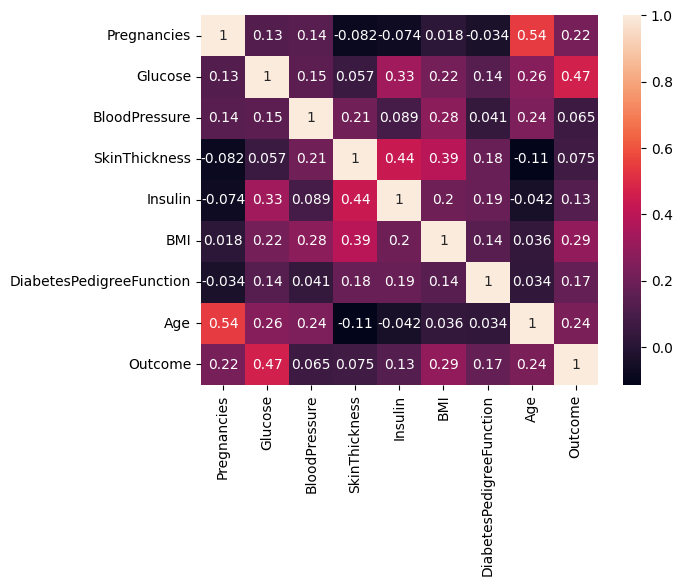

In [5]:
sns.heatmap(df_diabetes.corr(), annot=True)
plt.show()

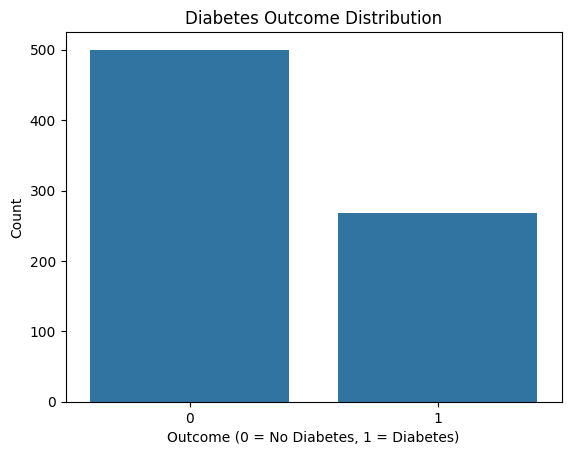

In [6]:
sns.countplot(x="Outcome", data=df_diabetes)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

In [7]:
df_diabetes.drop(["SkinThickness", "BloodPressure"], axis=1, inplace=True)
df_diabetes

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,0,33.6,0.627,50,1
1,1,85,0,26.6,0.351,31,0
2,8,183,0,23.3,0.672,32,1
3,1,89,94,28.1,0.167,21,0
4,0,137,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...
763,10,101,180,32.9,0.171,63,0
764,2,122,0,36.8,0.340,27,0
765,5,121,112,26.2,0.245,30,0
766,1,126,0,30.1,0.349,47,1


In [8]:
X = df_diabetes.iloc[:, 0:6].values
X


array([[  6.   , 148.   ,   0.   ,  33.6  ,   0.627,  50.   ],
       [  1.   ,  85.   ,   0.   ,  26.6  ,   0.351,  31.   ],
       [  8.   , 183.   ,   0.   ,  23.3  ,   0.672,  32.   ],
       ...,
       [  5.   , 121.   , 112.   ,  26.2  ,   0.245,  30.   ],
       [  1.   , 126.   ,   0.   ,  30.1  ,   0.349,  47.   ],
       [  1.   ,  93.   ,   0.   ,  30.4  ,   0.315,  23.   ]],
      shape=(768, 6))

In [9]:
Y = df_diabetes.iloc[:, 6].values
Y



array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [10]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling is a must in ANN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(768, 6)

In [11]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into the Training set and Test set
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (614, 6)
Y_train shape: (614,)
X_test shape: (154, 6)
Y_test shape: (154,)


# STEP #3: TRAIN THE MODEL

In [60]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(400, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Adding dropout to prevent overfitting
    tf.keras.layers.Dense(600, activation='relu'),
    tf.keras.layers.Dropout(0.3), # Adding dropout to prevent overfitting
    tf.keras.layers.Dense(800, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Adding dropout to prevent overfitting
    tf.keras.layers.Dense(1000, activation='relu'),
    tf.keras.layers.Dense(1000, activation='relu'),
    tf.keras.layers.Dense(1000, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Adding dropout to prevent overfitting
    tf.keras.layers.Dense(800, activation='relu'),
    tf.keras.layers.Dropout(0.3), # Adding dropout to prevent overfitting
    tf.keras.layers.Dense(600, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Adding dropout to prevent overfitting
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [61]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 400)            │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 600)            │       240,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 800)            │       480,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1000)           │       801,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 800)            │       800,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 600)            │       480,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │           601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,809,201 (18.35 MB)

 Trainable params: 4,809,201 (18.35 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [63]:
with tf.device("/GPU:0"):
    epochs_history = model.fit(X_train, Y_train, epochs=200)
    print("Training finished.")
    print("Learned weight:", model.layers[0].get_weights()[0][0][0])
    print("Learned bias:", model.layers[0].get_weights()[1][0])
    print("Initial loss:", float(epochs_history.history["loss"][0]))
    print("Final loss:", float(epochs_history.history["loss"][-1]))
    print("Initial accuracy:", float(epochs_history.history["accuracy"][0]))
    print("Final accuracy:", float(epochs_history.history["accuracy"][-1]))

Epoch 1/200


I0000 00:00:1774127112.453479  162326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_82826__.21


 1/20 ━━━━━━━━━━━━━━━━━━━━ 1:24 4s/step - accuracy: 0.3125 - loss: 0.6979

I0000 00:00:1774127116.033961  162327 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_82826__.21


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.6401 - loss: 0.6177
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7655 - loss: 0.4810 
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7671 - loss: 0.4684 
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7704 - loss: 0.4864 
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7736 - loss: 0.5035
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7752 - loss: 0.4672 
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7752 - loss: 0.4713 
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7557 - loss: 0.4896 
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4640 
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7769 - loss: 0.4709 
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4626 
Epoch 12/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 

# STEP#5: EVALUATING THE MODEL

In [64]:
epochs_history.history.keys()

dict_keys(['accuracy', 'loss'])

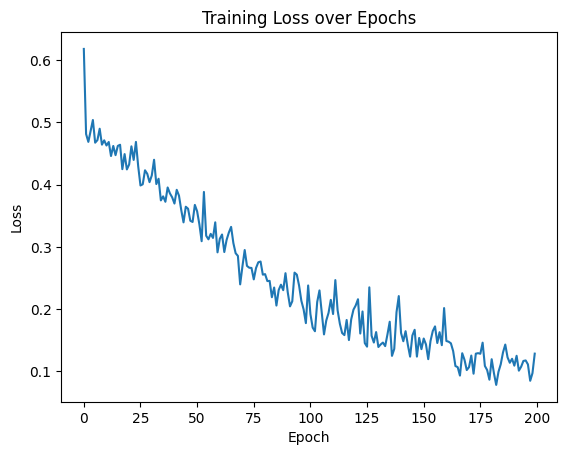

In [65]:
plt.plot(epochs_history.history["loss"], label="Training Loss")
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

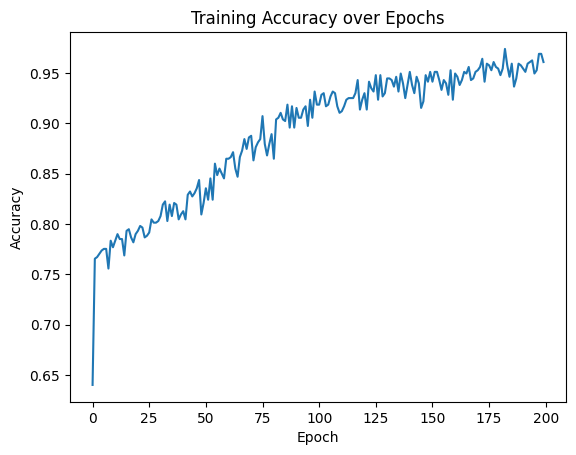

In [66]:
plt.plot(epochs_history.history["accuracy"], label="Training Accuracy")
plt.title("Training Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [67]:
# Training set Performance
Y_pred_train = model.predict(X_train)
Y_pred_train = (Y_pred_train > 0.5)
Y_pred_train

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step 


array([[False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [

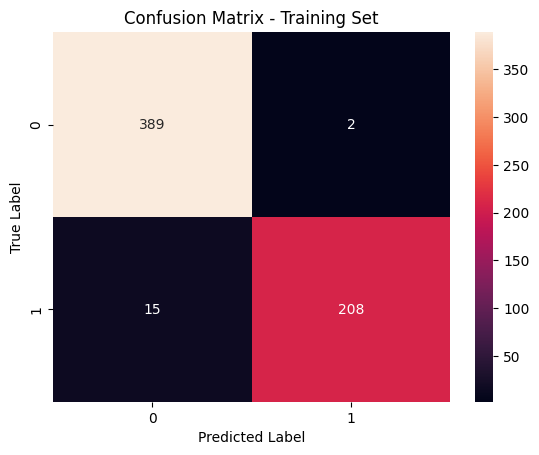

In [68]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_train, Y_pred_train)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Training Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [69]:
from sklearn.metrics import classification_report
print("Classification Report - Training Set:")
print(classification_report(Y_train, Y_pred_train))

Classification Report - Training Set:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       391
           1       0.99      0.93      0.96       223

    accuracy                           0.97       614
   macro avg       0.98      0.96      0.97       614
weighted avg       0.97      0.97      0.97       614



1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ -1s -205265us/step


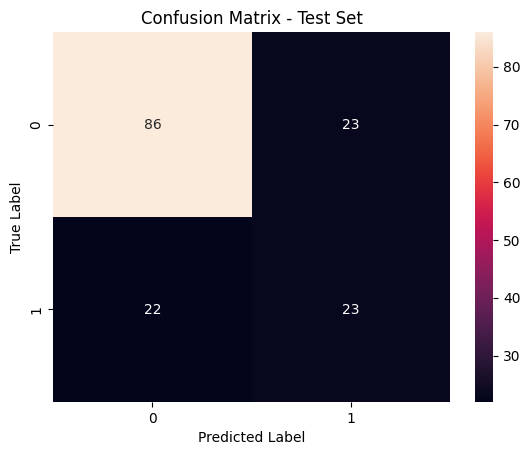

In [70]:
# Testing Set Performance
Y_pred_test = model.predict(X_test)
Y_pred_test = (Y_pred_test > 0.5)
cm = confusion_matrix(Y_test, Y_pred_test)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [71]:
print("Classification Report - Test Set:")
print(classification_report(Y_test, Y_pred_test))

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.80      0.79      0.79       109
           1       0.50      0.51      0.51        45

    accuracy                           0.71       154
   macro avg       0.65      0.65      0.65       154
weighted avg       0.71      0.71      0.71       154



# EXCELLENT JOB! YOU SHOULD BE PROUD OF YOUR NEWLY ACQUIRED SKILLS